# Drift Chamber Geant4 Sim Data Analysis

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
from mpl_toolkits import mplot3d
import pandas as pd
import random

#%matplotlib widget

In [3]:
# Get gas hit data
events_df = pd.read_csv(f'csv/hits/event_action_data.csv')
events_df['energies_'] = events_df['energies'].str.split('|')
events_df['hitx_'] = events_df['hitx'].str.split('|')
events_df['hity_'] = events_df['hity'].str.split('|')
events_df['hitz_'] = events_df['hitz'].str.split('|')
events_df = events_df.drop(columns=['energies', 'hitx', 'hity', 'hitz'])

# Get initial step data
steps_df = pd.read_csv(f'csv/hits/init_step_data.csv')

In [4]:
def data_for_cylinder(r_outer, r_inner, res, height):
    theta = np.linspace(0, 2 * np.pi, res)
    z = np.linspace(-height, height, res)
    theta_grid, z_grid = np.meshgrid(theta, z)
    
    x_grid = r_outer * np.cos(theta_grid)
    y_grid = r_outer * np.sin(theta_grid)
    
    return x_grid, y_grid, z_grid

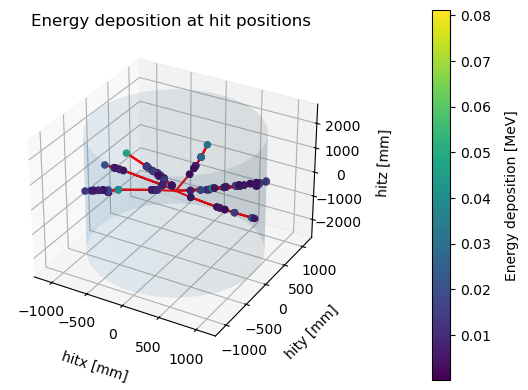

In [5]:
def plot_Edep_per_hit(df, num):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    
    hitx = []
    hity = []
    hitz = []
    energies = []
    
    Xc,Yc,Zc = data_for_cylinder(1096, 160, 100, 2416.9)
    ax.plot_surface(Xc, Yc, Zc, alpha=0.1)
    
    for i in range(0, num):
        cur_row = df.loc[i]
    
        try:
            energies += [float(x) for x in cur_row['energies_'][:-1]]
            x = [float(x) for x in cur_row['hitx_'][:-1]]
            y = [float(y) for y in cur_row['hity_'][:-1]]
            z = [float(z) for z in cur_row['hitz_'][:-1]]

        except:
            continue
    
        ax.plot3D([0.]+x, [0.]+y, [0.]+z, 'red')
    
        hitx += x
        hity += y
        hitz += z
    
    img = ax.scatter(hitx, hity, hitz, c=energies, cmap='viridis', alpha=1.0)
    
    cbar = fig.colorbar(img, ax=ax, pad=0.2)
    cbar.set_label("Energy deposition [MeV]", labelpad=10)
    
    plt.title("Energy deposition at hit positions")
    ax.set_xlabel('hitx [mm]', labelpad=10)
    ax.set_ylabel('hity [mm]', labelpad=10)
    ax.set_zlabel('hitz [mm]', labelpad=10)


num_to_plot = 10
plot_Edep_per_hit(events_df, num_to_plot)

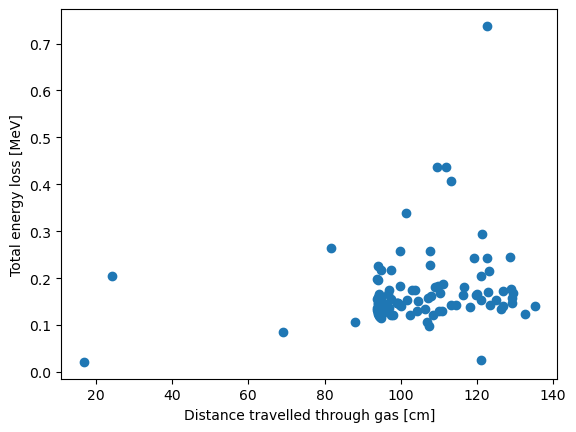

In [9]:
def plot_Eloss_over_dist(df1, df2):
    totE = []
    dist = []
    
    count = 0
    
    for i in range(len(events_df)):
        cur_event = df1.loc[i]
        cur_step = df2.loc[count]
    
        if not cur_event["num_hits"]: continue
        
        totE.append(sum([float(x) for x in cur_event['energies_'][:-1]])) 
        dist.append(cur_step["tot_dist"])
        count += 1
    
    totE = np.array(totE)
    tot_dis = np.array(dist) * 0.1
    
    plt.scatter(tot_dis, totE)
    plt.xlabel("Distance travelled through gas [cm]")
    plt.ylabel("Total energy loss [MeV]")

    return tot_dis

tot_dis = plot_Eloss_over_dist(events_df, steps_df)

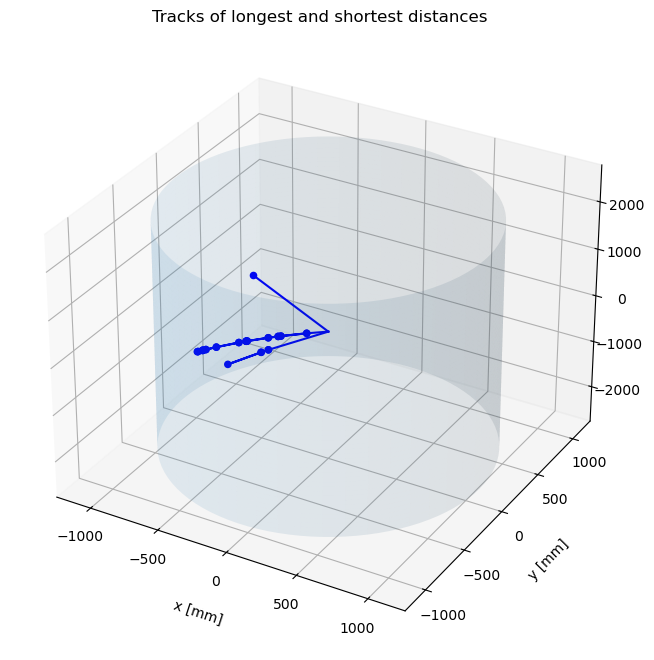

In [17]:
def plot_outliers(tot_dis):
    small_x, small_y, small_z = [], [], []
    
    for i in range(len(tot_dis)):
        cur_event = events_df.loc[i]
        if not cur_event["num_hits"]: continue
        
        if tot_dis[i] < 80:
            small_x.append([float(x) for x in cur_event['hitx_'][:-1]])
            small_y.append([float(y) for y in cur_event['hity_'][:-1]])
            small_z.append([float(z) for z in cur_event['hitz_'][:-1]])
    
    fig = plt.figure(figsize=(8,10))
    ax = fig.add_subplot(projection='3d')
        
    Xc,Yc,Zc = data_for_cylinder(1096, 160, 100, 2416.9)
    ax.plot_surface(Xc, Yc, Zc, alpha=0.1)
    
    for i in range(len(small_x)):
        ax.plot3D([0.]+small_x[i], [0.]+small_y[i], [0.]+small_z[i], 'blue')
        ax.scatter(small_x[i], small_y[i], small_z[i], alpha=1.0, color="blue")
    
    ax.set_xlabel('x [mm]', labelpad=10)
    ax.set_ylabel('y [mm]', labelpad=10)
    ax.set_zlabel('z [mm]', labelpad=10)
    ax.set_title("Tracks of longest and shortest distances")

plot_outliers(tot_dis)